# Event alignment demo
This demo shows how to align video recordings with ephys data when using the camera's strobe function.

*Make sure you have installed the conda environment and set the kernel to `neurokinematics` or `neurokinematics_cuda` depending on install.*

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from neurokinematics.multi_modal.alignment import detect_camera_on

Start by loading the sample analog data and checking the available keys. This data was recorded using the Open Ephys acquisition system, but this code is designed to work with any analog signal as long as you have the acquisition sample rate and the camera frame rate.

In [2]:
# create data path
project_root = Path.cwd().parent

data_path = project_root / 'examples' / 'sample_data' / 'continuous_event_test_data.npz'

# load test data
data = np.load(data_path)
print(f"Available arrays: {data.files}")

Available arrays: ['signal', 'sample_rate', 'camera_fps']


Create variables for the analog signal (`signal`, voltage/arbitrary units), acquisition system sampling rate (`sample_rate`, Hz), and camera frame rate (`fps`, Hz).

In [3]:
# create variables
signal = data['signal']
sample_rate = data['sample_rate']
fps = data['camera_fps']

For this demo, the `signal` variable will need to be padded due to the short length (700 samples, ~23ms). This is an unnecessary intermediate step for test cases given that most ephys recordings will be significantly longer than this.

In [4]:
# pad signal snippet
signal_pad = np.pad(signal, 1000, mode='minimum')

A dictionary of detection settings is also needed for the `detect_camera_on` function. In the full pipeline, this is done with a config file. This demo will pull the detection settings from a config file, but these settings can be created with a dictionary. The dictionary should have the keys `fps`, `threshold_ratio`, `minimum_bout_duration`, and `bandwidth`. 

In [5]:
from neurokinematics.io import load_config

cfg = load_config('camera_alignment_cfg.yaml', config_type='multimodal')
detection_settings = cfg['detection_settings']

# detection_settings = {'fps': 200., 'threshold_ratio': 0.3, 'minimum_bout_duration': 0.1, 'bandwidth': 40} # this is the same as a dictionary

print('Key-value pairs in detection settings')
for key, val in detection_settings.items():
    print(f"{key}: {val}")

Key-value pairs in detection settings
fps: 200.0
threshold_ratio: 0.3
minimum_bout_duration: 0.1
bandwidth: 40.0


The `minimum_bout_duration` variable is useful for scenarios where ephys recordings are continuous and video recordings are discontinuous as it allows you to filter for edge cases where video recordings are triggered without the subject being in frame. In this example, however, we will set the `mininmum_bout_duration` to 0.0 as the signal is very short.

In [6]:
detection_settings['minimum_bout_duration'] = 0.0 # quick fix for demo
print('Updated key-value pairs in detection settings')
for key, val in detection_settings.items():
    print(f"{key}: {val}")

Updated key-value pairs in detection settings
fps: 200.0
threshold_ratio: 0.3
minimum_bout_duration: 0.0
bandwidth: 40.0


With the padded signal `signal_pad`, acquisition sample rate `sample_rate`, and the detection settings, we can identify the indices where camera frames were captured by running `detect_camera_on`, which will return a pandas dataframe containing information about the frame captures relative to the ephys recording.

In [7]:
# extract the frame captures
_, _, _, fc_df = detect_camera_on(signal_pad, sample_rate, detection_settings, save_path=None)

# examine data frame
fc_df.head()

,video_index,frame_id,sample_index
0,0,0,1277
1,0,1,1427
2,0,2,1577


We can plot the frame capture indices against the analog data recorded on the ephys acquisition system to see that the frames line up with the strobe. Note: depending on how you physically set up your strobe, the voltage may be higher or lower than this example.

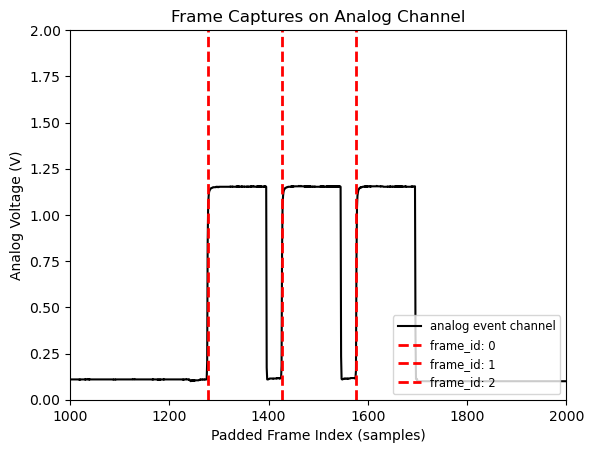

In [8]:
# plot results

plt.plot(signal_pad*0.0001525879,label='analog event channel', color='black') # padded signal multiplied by ADC bitVolts

# loop through sample indices
for i, x in enumerate(fc_df['sample_index']):
    plt.axvline(x, linestyle='--', linewidth=2, color='red', label=f'frame_id: {i}')
plt.ylim(0,2.) 
plt.title('Frame Captures on Analog Channel')
plt.xlabel('Padded Frame Index (samples)')
plt.ylabel('Analog Voltage (V)')
plt.xlim([1000,2000]) # zoom in on three captures
plt.legend(fontsize='small', loc='lower right')
plt.show()